The goal to compress a 24 bit image into 4 bit image using K_Mean Algorithm

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
original_img = plt.imread("./data/images/bird_small.png")

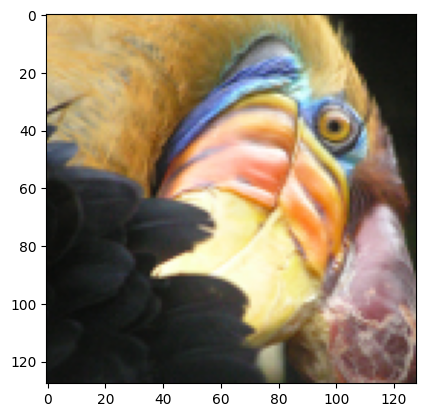

In [4]:
plt.imshow(original_img)

In [9]:
arr_img = np.array(original_img)
img_matrix = arr_img.reshape(arr_img.shape[0]*arr_img.shape[1], arr_img.shape[2])

In [18]:
def centroids_initalize(img, K):

    r_id = np.random.permutation(img.shape[0])

    return img[r_id[:K]]

In [98]:
def compute_nearest_k(x, centroids):

    idx = np.zeros(x.shape[0])

    transformed_x = x[:, np.newaxis, :]
    cal_matrix = transformed_x - centroids
    # print(cal_matrix)
    cal_matrix = np.power(cal_matrix, 2)
    cal_matrix = np.sum(cal_matrix, axis=-1)
    print(cal_matrix.shape)
    idx = np.argmin(cal_matrix, axis=1)
    return idx
    

In [87]:
centroids = centroids_initalize(img_matrix, 3)
c_id = compute_nearest_k(img_matrix, centroids)

[[[-0.14117646 -0.0745098  -0.16862747]
  [ 0.7607843   0.6117647   0.30588236]
  [ 0.44705883  0.3254902   0.21568628]]

 [[-0.09803921 -0.05490196 -0.11764708]
  [ 0.8039216   0.6313726   0.35686275]
  [ 0.49019608  0.34509805  0.26666665]]

 [[-0.11372548 -0.05098039 -0.14117649]
  [ 0.7882353   0.63529414  0.33333334]
  [ 0.4745098   0.34901962  0.24313726]]

 ...

 [[-0.745098   -0.6117647  -0.41960788]
  [ 0.15686277  0.07450981  0.05490196]
  [-0.15686274 -0.21176471 -0.03529412]]

 [[-0.77254903 -0.63529414 -0.42352945]
  [ 0.12941176  0.0509804   0.0509804 ]
  [-0.18431373 -0.23529412 -0.03921568]]

 [[-0.79607844 -0.627451   -0.43921572]
  [ 0.10588235  0.05882353  0.03529412]
  [-0.20784314 -0.22745098 -0.05490196]]]


In [90]:
def compute_k_mean(x, id, centroids):

    m = centroids.shape[0]
    new_centroids = np.zeros((m, centroids.shape[1]))
    itr = 0

    for elements in range(m):
        index = np.where(id == elements)
        group = x[index]
        mean = np.mean(group, axis=0)
        new_centroids[itr] = mean
        itr += 1
    return new_centroids

In [96]:
def run_k_mean(x, itr, k):

    centroids = centroids_initalize(x, k)
    # print(f" values of centroids :{centroids}")

    for i in range(itr):

        c_idx = compute_nearest_k(x, centroids)

        print(np.unique(c_idx))

        centroids = compute_k_mean(x, c_idx, centroids)
        # print(f"iteration :{i}, values of centroids :{centroids}")

    return centroids

In [101]:
converged_centroids = run_k_mean(img_matrix, 10, 16)

(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16384, 16)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [102]:
idx = compute_nearest_k(img_matrix, converged_centroids)

(16384, 16)


In [103]:
image_recover = converged_centroids[idx, :]

In [104]:
image = np.reshape(image_recover, arr_img.shape)

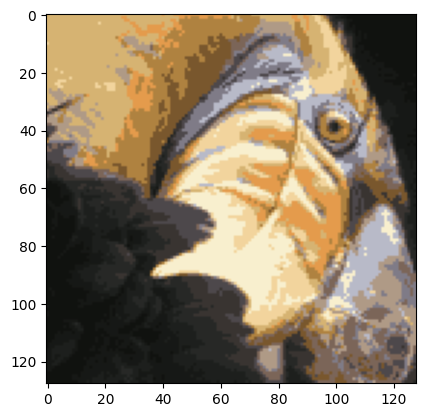

In [107]:
plt.imshow(image)

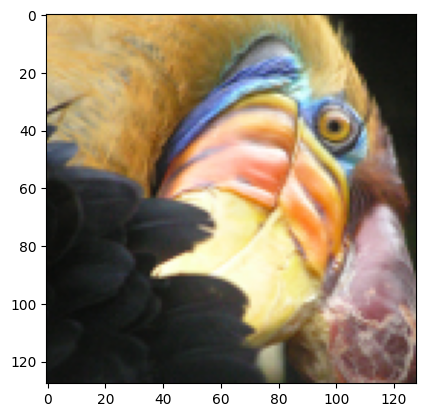

In [108]:
plt.imshow(arr_img)